# Car Crash Severity Prediction


---
## 0. Imports & Setup

In [29]:
# ── Standard Libraries ──────────────────────────────────────────────────────
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# ── Scikit-learn: Pre-processing ─────────────────────────────────────────────
from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV, StratifiedKFold
from sklearn.preprocessing import LabelEncoder, StandardScaler, MinMaxScaler
from sklearn.pipeline import Pipeline

# ── Scikit-learn: Models ─────────────────────────────────────────────────────
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.ensemble import RandomForestClassifier
from sklearn.neural_network import MLPClassifier
from sklearn.preprocessing import OneHotEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import GaussianNB

# ── Scikit-learn: Metrics ─────────────────────────────────────────────────────
from sklearn.metrics import (
    accuracy_score, classification_report, confusion_matrix,
    f1_score, roc_auc_score, ConfusionMatrixDisplay
)


---
## 1. Load Dataset

In [51]:
train_path = r"C:\Users\ganna\Downloads\car_crash_train.csv"
train_df = pd.read_csv(train_path)   # labeled training data

test_path = r"C:\Users\ganna\Downloads\car_crash_test.csv"
test_df  = pd.read_csv(test_path)    # unlabeled test data (for Kaggle submission)

print(f"Training set shape : {train_df.shape}")
print(f"Test set shape     : {test_df.shape}")
train_df.head()

Training set shape : (4000, 19)
Test set shape     : (1000, 19)


,Crash Speed (km/h),Impact Angle (degrees),Airbag Deployed,Seatbelt Used,Weather Conditions,Road Conditions,Crash Type,Vehicle Type,Vehicle Age (years),Brake Condition,Tire Condition,Driver Age,Driver Experience (years),Alcohol Level (BAC%),Distraction Level,Time of Day,Traffic Density,Visibility Distance (m),Severity
0,182,69,Yes,No,Clear,Dry,Rollover,Sedan,5,Good,Good,23,11,0.025314,NaN,Morning,Low,213,Minor Injury
1,192,73,Yes,No,Clear,Dry,Head-on,Truck,3,Good,Good,29,27,0.002372,Phone,Morning,Medium,426,Minor Injury
2,114,77,No,Yes,Clear,Dry,Head-on,Sedan,16,Good,Worn out,73,45,0.000483,NaN,Morning,Medium,175,Minor Injury
3,93,14,No,Yes,Clear,Dry,Rear-end,Truck,14,Worn out,Worn out,27,18,0.176578,NaN,Afternoon,Medium,82,Minor Injury
4,170,96,No,Yes,Clear,Dry,Side impact,SUV,15,Good,Good,70,27,0.065696,Other,Morning,Medium,96,Severe Injury


---
## 2. Exploratory Data Analysis (EDA)

### 2.1 Basic Info & Data Types

In [52]:
print("=== Dataset Info ===")
train_df.info()
missing_per_column = train_df.isnull().sum()
missing_per_column = missing_per_column[missing_per_column > 0]

missing_df = missing_per_column.reset_index()
missing_df.columns = ['Column', 'Missing Count']

print(missing_df)
print("\nTotal missing values in dataset:", missing_df['Missing Count'].sum())

missing_columns = train_df.columns[train_df.isnull().any()]

print("Columns with missing values:")
print(missing_columns.tolist())


=== Dataset Info ===
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4000 entries, 0 to 3999
Data columns (total 19 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   Crash Speed (km/h)         4000 non-null   int64  
 1   Impact Angle (degrees)     4000 non-null   int64  
 2   Airbag Deployed            4000 non-null   object 
 3   Seatbelt Used              4000 non-null   object 
 4   Weather Conditions         4000 non-null   object 
 5   Road Conditions            4000 non-null   object 
 6   Crash Type                 4000 non-null   object 
 7   Vehicle Type               4000 non-null   object 
 8   Vehicle Age (years)        4000 non-null   int64  
 9   Brake Condition            4000 non-null   object 
 10  Tire Condition             4000 non-null   object 
 11  Driver Age                 4000 non-null   int64  
 12  Driver Experience (years)  4000 non-null   int64  
 13  Alcohol Level (BAC%)       

=== Chi-Square Test: Distraction Level vs Categorical Features ===

Time of Day               → p=0.86177  ❌ Not significant
Crash Type                → p=0.47108  ❌ Not significant
Vehicle Type              → p=0.87689  ❌ Not significant
Airbag Deployed           → p=0.52533  ❌ Not significant
Seatbelt Used             → p=0.44387  ❌ Not significant

=== ANOVA Test: Distraction Level vs Numerical Features ===

Crash Speed (km/h)        → p=0.74756  ❌ Not significant
Driver Age                → p=0.89243  ❌ Not significant


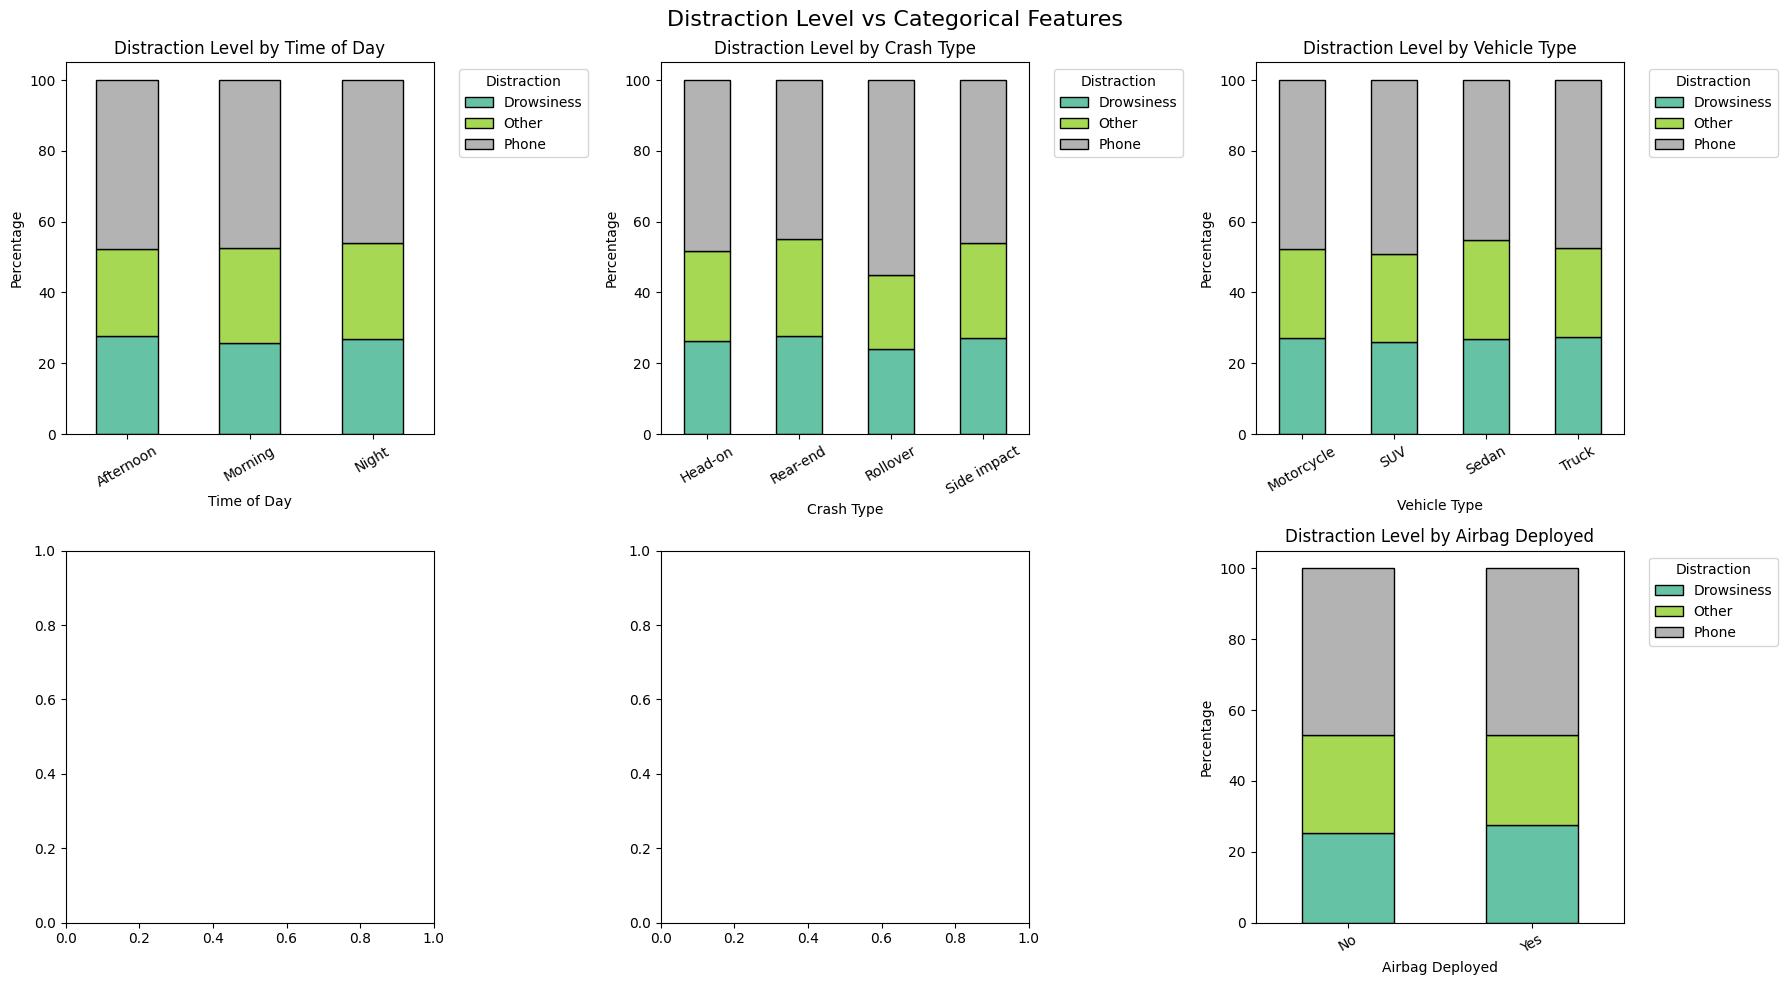

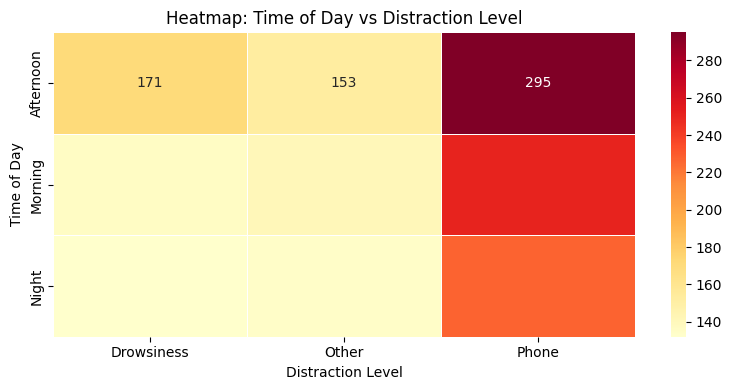

In [53]:
import scipy.stats as stats

# ── 1. Separate rows where Distraction Level is NOT missing ──────────────────
df_known = train_df[train_df['Distraction Level'].notna()].copy()

# ── 2. Chi-Square Test: Distraction vs Categorical Columns ───────────────────
# Chi-square tells us if two categorical variables are statistically related
cat_cols_to_test = ['Time of Day', 'Crash Type', 'Vehicle Type', 
                    'Weather Condition', 'Road Condition', 'Airbag Deployed',
                    'Seatbelt Used']

print("=== Chi-Square Test: Distraction Level vs Categorical Features ===\n")
chi2_results = []

for col in cat_cols_to_test:
    if col in df_known.columns:
        ct = pd.crosstab(df_known['Distraction Level'], df_known[col])
        chi2, p, dof, expected = stats.chi2_contingency(ct)
        chi2_results.append({'Feature': col, 'Chi2': round(chi2, 3), 'p-value': round(p, 5)})
        significance = "✅ Significant" if p < 0.05 else "❌ Not significant"
        print(f"{col:25s} → p={p:.5f}  {significance}")

# ── 3. ANOVA Test: Distraction vs Numerical Columns ──────────────────────────
# ANOVA checks if the mean of a numerical feature differs across distraction groups
num_cols_to_test = ['Crash Speed (km/h)', 'Driver Age', 'Driver Experience',
                    'Alcohol Level', 'Impact Angle', 'Vehicle Age']

print("\n=== ANOVA Test: Distraction Level vs Numerical Features ===\n")
anova_results = []

for col in num_cols_to_test:
    if col in df_known.columns:
        groups = [group[col].dropna().values 
                  for _, group in df_known.groupby('Distraction Level')]
        f_stat, p = stats.f_oneway(*groups)
        anova_results.append({'Feature': col, 'F-stat': round(f_stat, 3), 'p-value': round(p, 5)})
        significance = "✅ Significant" if p < 0.05 else "❌ Not significant"
        print(f"{col:25s} → p={p:.5f}  {significance}")

# ── 4. Visualize: Distraction Level vs Top Features ──────────────────────────

# Categorical: stacked bar charts
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flatten()

for i, col in enumerate(cat_cols_to_test[:6]):
    if col in df_known.columns:
        ct = pd.crosstab(df_known[col], df_known['Distraction Level'], normalize='index') * 100
        ct.plot(kind='bar', stacked=True, ax=axes[i], colormap='Set2', edgecolor='black')
        axes[i].set_title(f'Distraction Level by {col}')
        axes[i].set_ylabel('Percentage')
        axes[i].tick_params(axis='x', rotation=30)
        axes[i].legend(title='Distraction', bbox_to_anchor=(1.05, 1), loc='upper left')

plt.suptitle('Distraction Level vs Categorical Features', fontsize=16)
plt.tight_layout()
plt.show()



# ── 5. Heatmap: Distraction Level vs Time of Day ─────────────────────────────
if 'Time of Day' in df_known.columns:
    ct = pd.crosstab(df_known['Time of Day'], df_known['Distraction Level'])
    plt.figure(figsize=(8, 4))
    sns.heatmap(ct, annot=True, fmt='d', cmap='YlOrRd', linewidths=0.5)
    plt.title('Heatmap: Time of Day vs Distraction Level')
    plt.tight_layout()
    plt.show()

In [36]:
print("=== Statistical Summary ===")
train_df.describe(include='all')

=== Statistical Summary ===


,Crash Speed (km/h),Impact Angle (degrees),Airbag Deployed,Seatbelt Used,Weather Conditions,Road Conditions,Crash Type,Vehicle Type,Vehicle Age (years),Brake Condition,Tire Condition,Driver Age,Driver Experience (years),Alcohol Level (BAC%),Distraction Level,Time of Day,Traffic Density,Visibility Distance (m),Severity
count,4000.000000,4000.000000,4000,4000,4000,4000,4000,4000,4000.000000,4000,4000,4000.000000,4000.000000,4000.000000,1640,4000,4000,4000.000000,4000
unique,NaN,NaN,2,2,4,4,4,4,NaN,2,2,NaN,NaN,NaN,3,3,3,NaN,3
top,NaN,NaN,Yes,Yes,Clear,Dry,Side impact,Sedan,NaN,Good,Good,NaN,NaN,NaN,Phone,Afternoon,Medium,NaN,Minor Injury
freq,NaN,NaN,2817,3174,2345,2792,1413,1644,NaN,3369,3225,NaN,NaN,NaN,773,1579,1979,NaN,2756
mean,110.999750,89.979750,NaN,NaN,NaN,NaN,NaN,NaN,9.445500,NaN,NaN,48.698750,24.723000,0.101216,NaN,NaN,NaN,247.583500,NaN
std,52.227839,51.301514,NaN,NaN,NaN,NaN,NaN,NaN,5.718147,NaN,NaN,17.815972,14.211818,0.057820,NaN,NaN,NaN,143.478155,NaN
min,20.000000,0.000000,NaN,NaN,NaN,NaN,NaN,NaN,0.000000,NaN,NaN,18.000000,0.000000,0.000054,NaN,NaN,NaN,10.000000,NaN
25%,66.000000,45.000000,NaN,NaN,NaN,NaN,NaN,NaN,5.000000,NaN,NaN,34.000000,13.000000,0.050630,NaN,NaN,NaN,120.000000,NaN
50%,112.000000,89.500000,NaN,NaN,NaN,NaN,NaN,NaN,9.000000,NaN,NaN,49.000000,25.000000,0.101574,NaN,NaN,NaN,244.000000,NaN
75%,157.000000,134.000000,NaN,NaN,NaN,NaN,NaN,NaN,14.000000,NaN,NaN,64.000000,37.000000,0.151783,NaN,NaN,NaN,372.000000,NaN


### 2.2 Target Variable Distribution

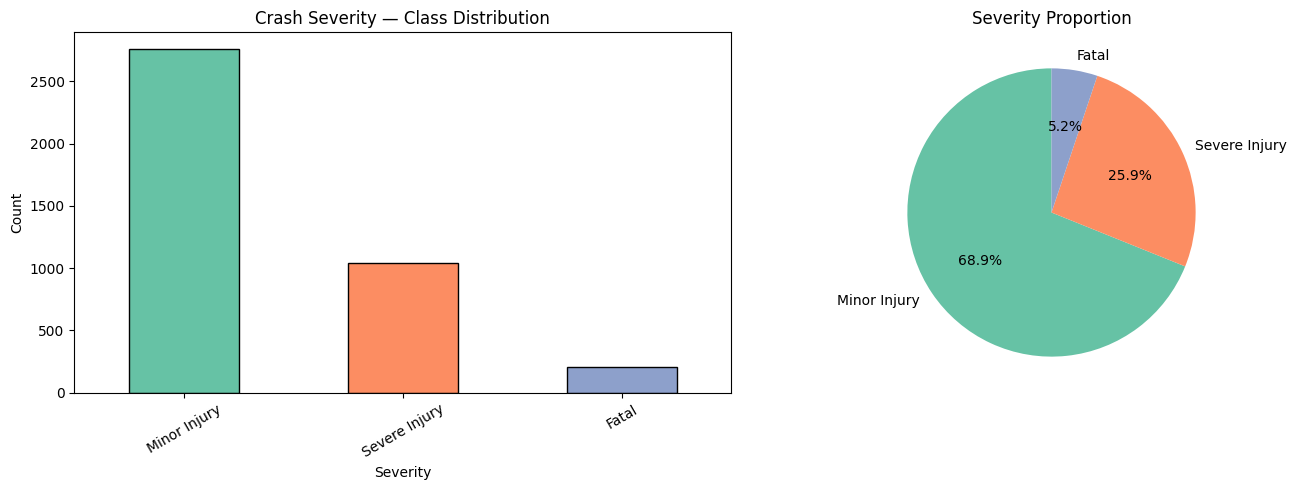


Class counts:
Severity
Minor Injury     2756
Severe Injury    1038
Fatal             206
Name: count, dtype: int64


In [37]:
target_col = 'Severity'
severity_counts = train_df[target_col].value_counts()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Bar chart
severity_counts.plot(kind='bar', ax=axes[0], color=sns.color_palette('Set2'), edgecolor='black')
axes[0].set_title('Crash Severity — Class Distribution')
axes[0].set_xlabel('Severity')
axes[0].set_ylabel('Count')
axes[0].tick_params(axis='x', rotation=30)

# Pie chart
axes[1].pie(severity_counts, labels=severity_counts.index, autopct='%1.1f%%',
            colors=sns.color_palette('Set2'), startangle=90)
axes[1].set_title('Severity Proportion')

plt.tight_layout()
plt.show()

print("\nClass counts:")
print(severity_counts)

# Comment:
# Observing whether the dataset is balanced or imbalanced is critical.
# If one class (e.g., 'Fatal') is heavily under-represented, we may need
# to apply class_weight='balanced' in our models or use oversampling.

### 2.3 Missing Values

Total missing values in the training set: 2360

Missing values per column:
                   Missing Count  Missing %
Distraction Level           2360       59.0


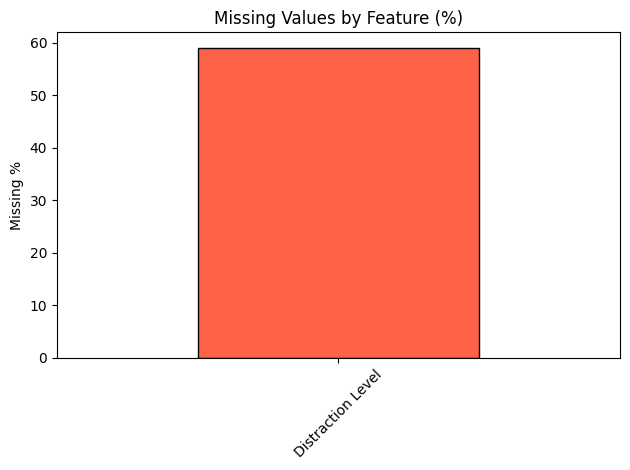

In [38]:
missing = train_df.isnull().sum()
total_missing = missing.sum()
missing_pct = (missing / len(train_df) * 100).round(2)
missing_df = pd.DataFrame({'Missing Count': missing, 'Missing %': missing_pct})
missing_df = missing_df[missing_df['Missing Count'] > 0].sort_values('Missing %', ascending=False)

print(f"Total missing values in the training set: {total_missing}")

if missing_df.empty:
    print("✅ No missing values found in the training set.")
else:
    print("\nMissing values per column:")
    print(missing_df)
    
    # Visualize
    missing_df['Missing %'].plot(kind='bar', color='tomato', edgecolor='black')
    plt.title('Missing Values by Feature (%)')
    plt.ylabel('Missing %')
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()

### 2.4 Numerical Feature Distributions

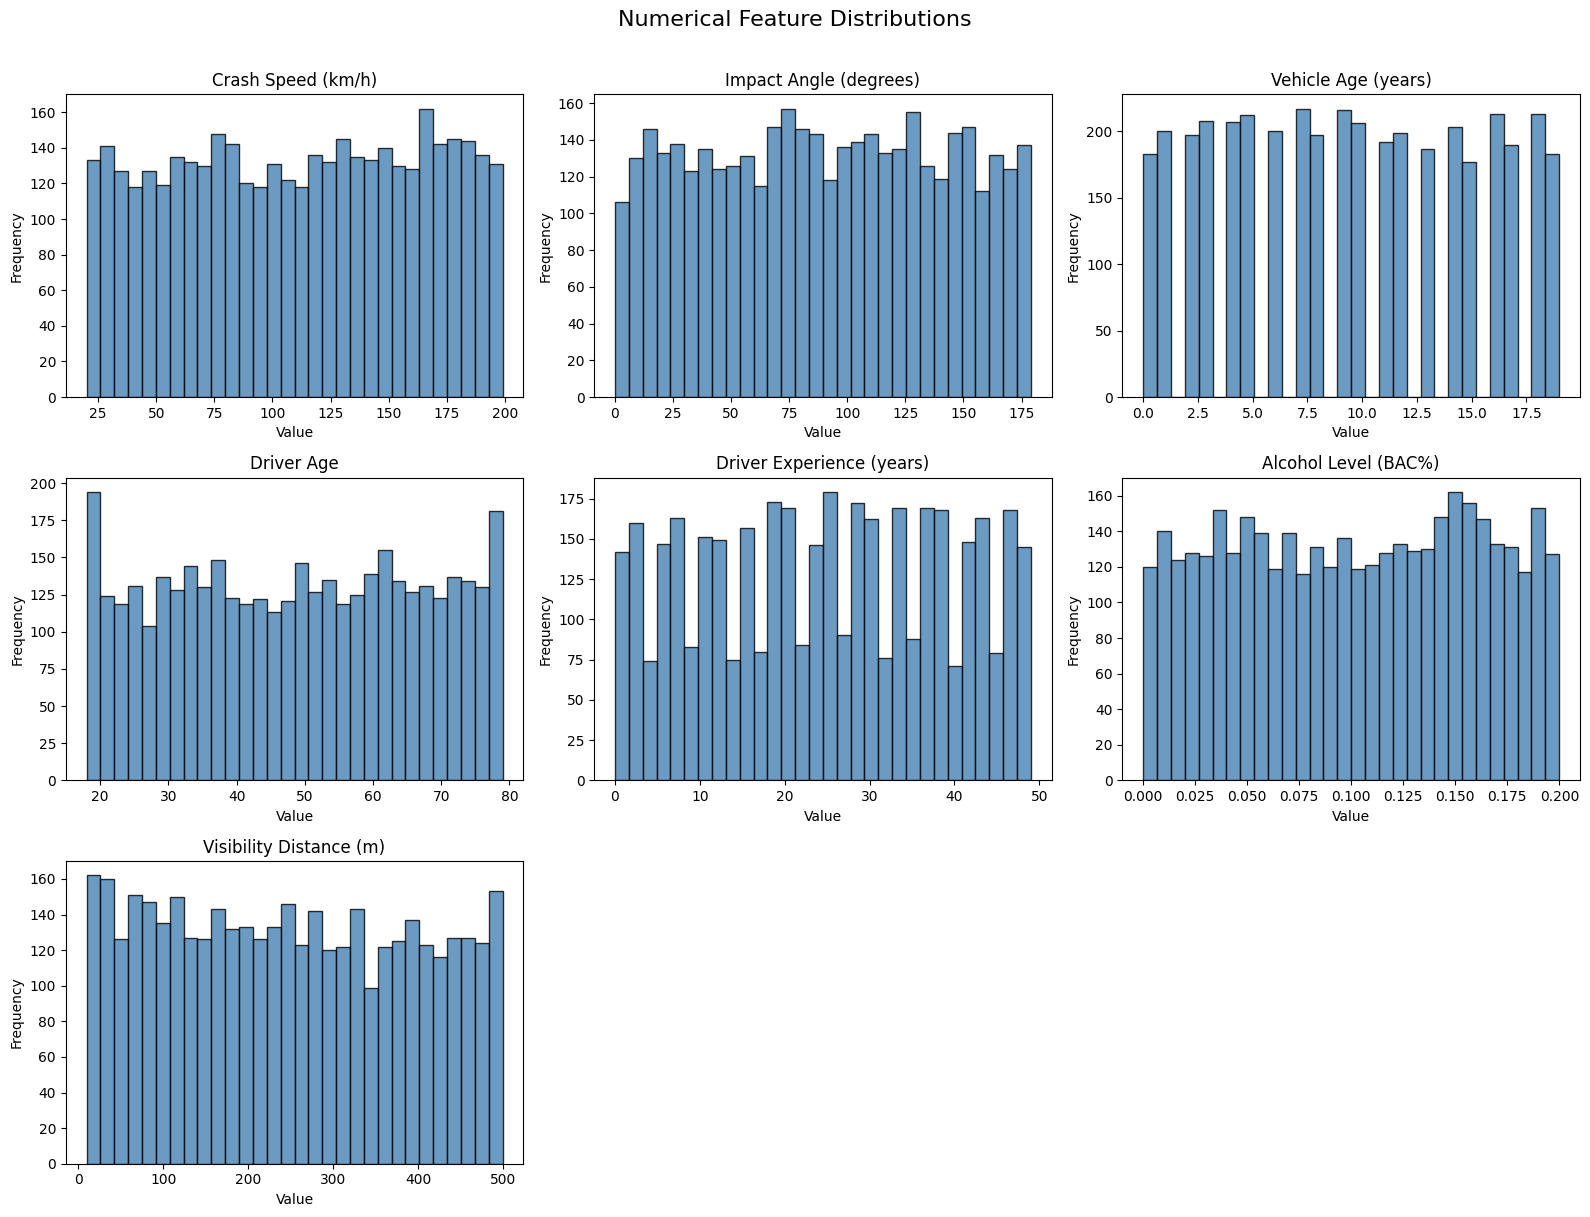

In [39]:
numerical_cols = train_df.select_dtypes(include=['int64', 'float64']).columns.tolist()
if target_col in numerical_cols:
    numerical_cols.remove(target_col)

n_cols = 3
n_rows = int(np.ceil(len(numerical_cols) / n_cols))

fig, axes = plt.subplots(n_rows, n_cols, figsize=(16, n_rows * 4))
axes = axes.flatten()

for i, col in enumerate(numerical_cols):
    axes[i].hist(train_df[col].dropna(), bins=30, color='steelblue', edgecolor='black', alpha=0.8)
    axes[i].set_title(col)
    axes[i].set_xlabel('Value')
    axes[i].set_ylabel('Frequency')

for j in range(i + 1, len(axes)):
    axes[j].set_visible(False)

plt.suptitle('Numerical Feature Distributions', fontsize=16, y=1.01)
plt.tight_layout()
plt.show()

# Comment:
# We check for skewness, outliers, and value ranges.
# Highly skewed features may benefit from log-transformation.
# Features on vastly different scales need standardization for distance-based models (KNN, LR).

Distribution Analysis:

All numerical features (Crash Speed, Impact Angle, Vehicle Age, Driver Age, Driver Experience, Alcohol Level, and Visibility Distance) follow a near-uniform distribution, meaning values are spread roughly equally across their entire range with no significant skewness or outliers.



### 2.5 Categorical Feature Distributions

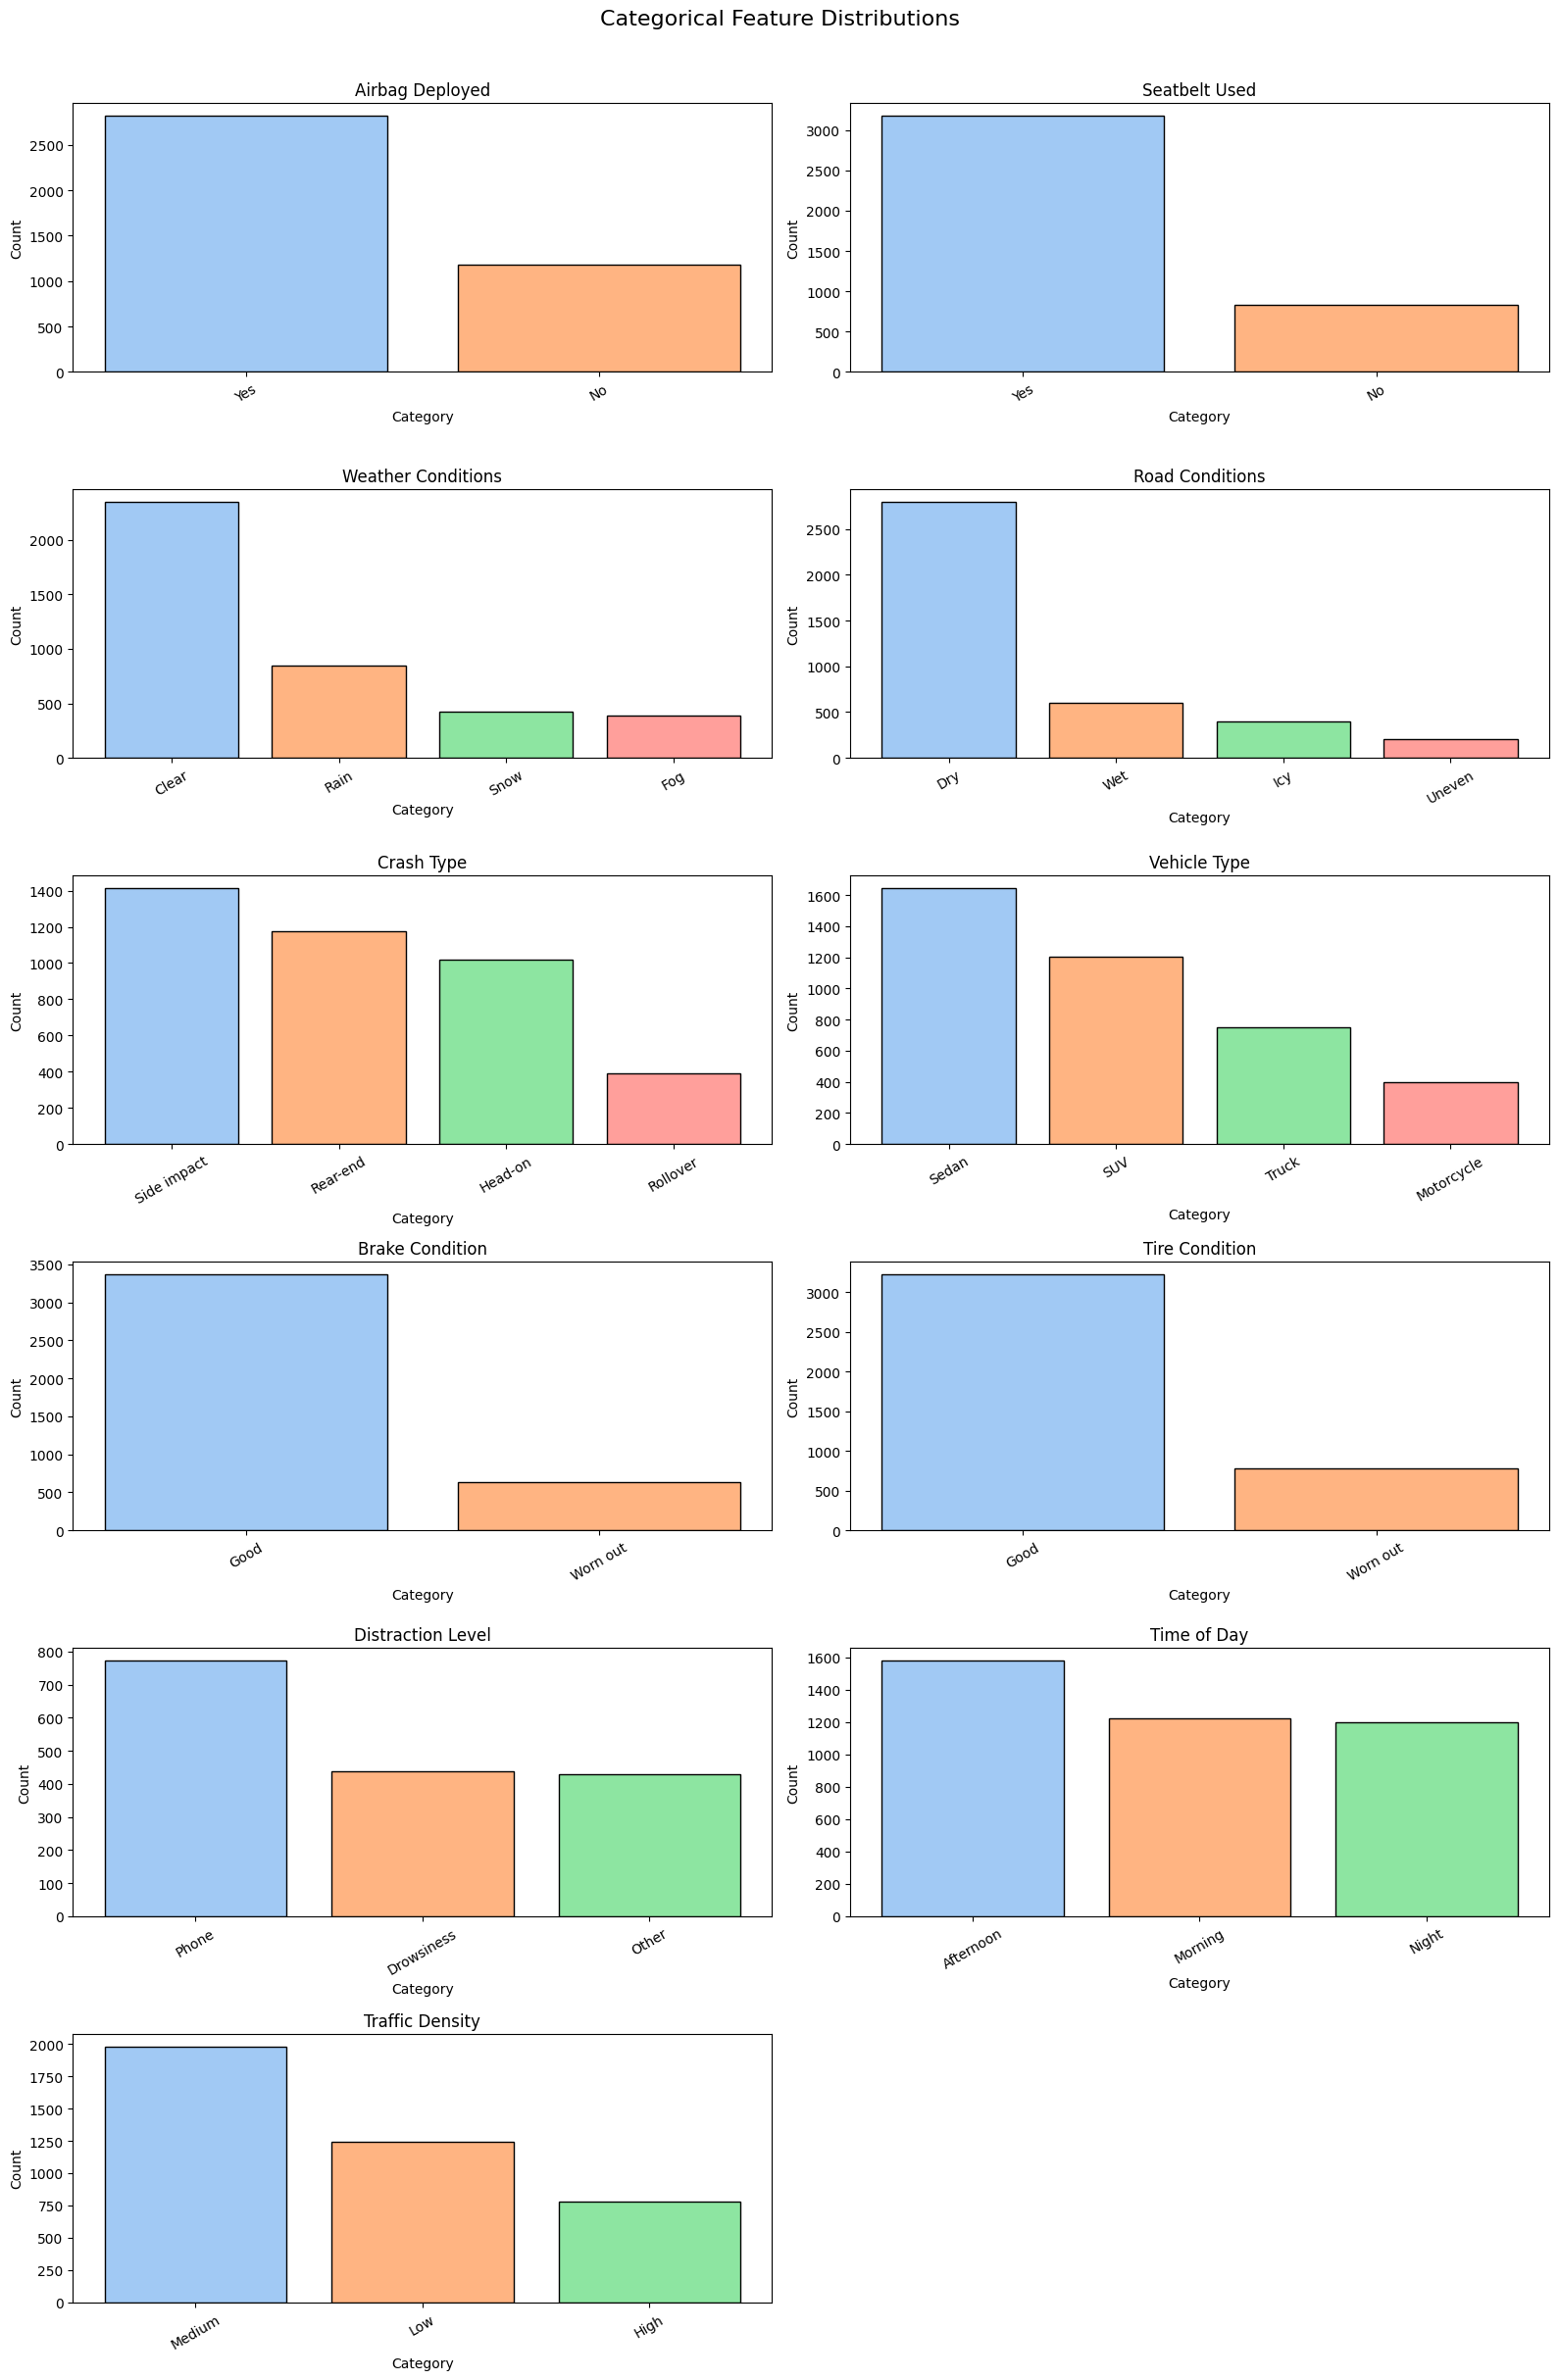

In [40]:
categorical_cols = train_df.select_dtypes(include=['object']).columns.tolist()
if target_col in categorical_cols:
    categorical_cols.remove(target_col)

n_cols = 2
n_rows = int(np.ceil(len(categorical_cols) / n_cols))

fig, axes = plt.subplots(n_rows, n_cols, figsize=(16, n_rows * 4))
axes = axes.flatten()

for i, col in enumerate(categorical_cols):
    counts = train_df[col].value_counts()
    axes[i].bar(counts.index, counts.values,
                color=sns.color_palette('pastel', len(counts)), edgecolor='black')
    axes[i].set_title(col)
    axes[i].set_xlabel('Category')
    axes[i].set_ylabel('Count')
    axes[i].tick_params(axis='x', rotation=30)

for j in range(i + 1, len(axes)):
    axes[j].set_visible(False)

plt.suptitle('Categorical Feature Distributions', fontsize=16, y=1.01)
plt.tight_layout()
plt.show()

In [41]:
#check for class imbalance in target variable
print(train_df['Severity'].value_counts())
print(train_df['Severity'].value_counts(normalize=True) * 100)

Severity
Minor Injury     2756
Severe Injury    1038
Fatal             206
Name: count, dtype: int64
Severity
Minor Injury     68.90
Severe Injury    25.95
Fatal             5.15
Name: proportion, dtype: float64


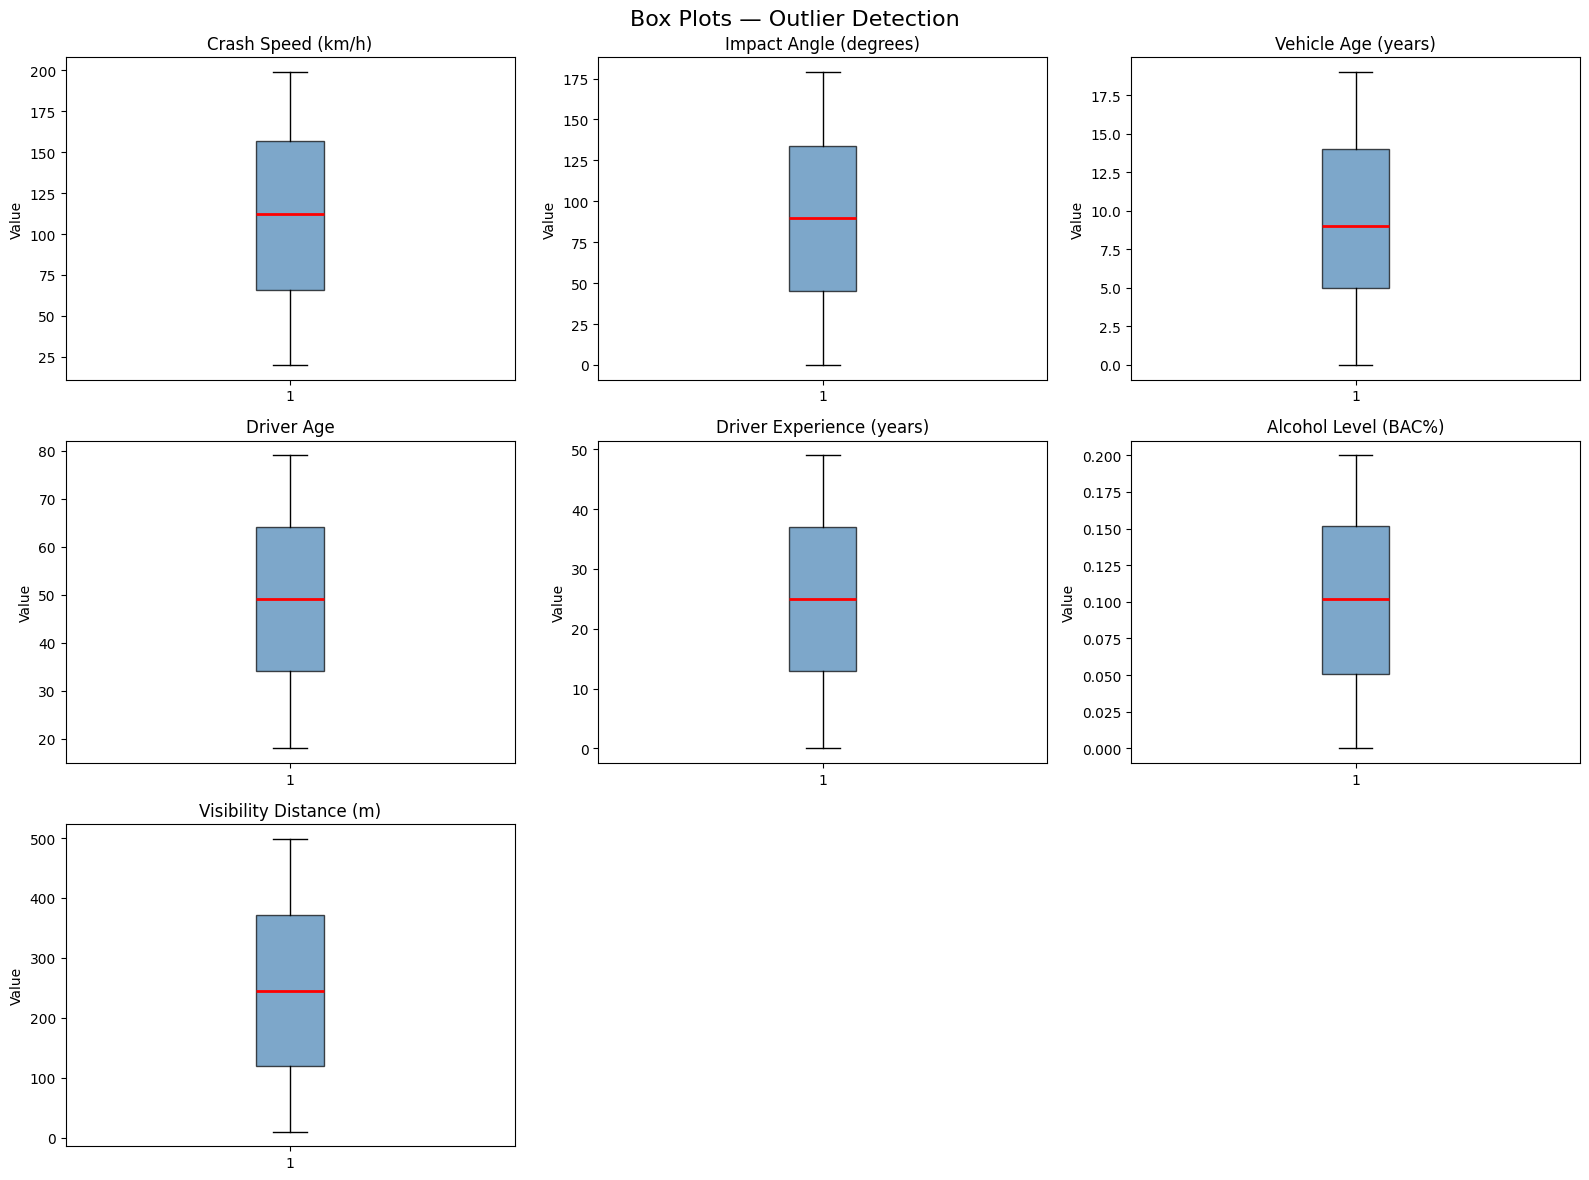

=== Outlier Count per Feature (IQR Method) ===

Crash Speed (km/h)             →    0 outliers (0.0%)
Impact Angle (degrees)         →    0 outliers (0.0%)
Vehicle Age (years)            →    0 outliers (0.0%)
Driver Age                     →    0 outliers (0.0%)
Driver Experience (years)      →    0 outliers (0.0%)
Alcohol Level (BAC%)           →    0 outliers (0.0%)
Visibility Distance (m)        →    0 outliers (0.0%)


In [42]:
# ── Outlier Detection 

numerical_cols = ['Crash Speed (km/h)', 'Impact Angle (degrees)', 'Vehicle Age (years)',
                  'Driver Age', 'Driver Experience (years)', 'Alcohol Level (BAC%)',
                  'Visibility Distance (m)']

# ── 1. Box Plots 
fig, axes = plt.subplots(3, 3, figsize=(16, 12))
axes = axes.flatten()

for i, col in enumerate(numerical_cols):
    axes[i].boxplot(train_df[col].dropna(), patch_artist=True,
                    boxprops=dict(facecolor='steelblue', alpha=0.7),
                    medianprops=dict(color='red', linewidth=2))
    axes[i].set_title(col)
    axes[i].set_ylabel('Value')

for j in range(i+1, len(axes)):
    axes[j].set_visible(False)

plt.suptitle('Box Plots — Outlier Detection', fontsize=16)
plt.tight_layout()
plt.show()

# ── 2. IQR Method — Count Outliers Per Feature 
print("=== Outlier Count per Feature (IQR Method) ===\n")

outlier_summary = []

for col in numerical_cols:
    Q1  = train_df[col].quantile(0.25)
    Q3  = train_df[col].quantile(0.75)
    IQR = Q3 - Q1
    
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    
    outliers = train_df[(train_df[col] < lower_bound) | (train_df[col] > upper_bound)]
    n_outliers = len(outliers)
    pct = round(n_outliers / len(train_df) * 100, 2)
    
    outlier_summary.append({
        'Feature'    : col,
        'Q1'         : round(Q1, 3),
        'Q3'         : round(Q3, 3),
        'IQR'        : round(IQR, 3),
        'Lower Bound': round(lower_bound, 3),
        'Upper Bound': round(upper_bound, 3),
        'N Outliers' : n_outliers,
        'Outlier %'  : pct
    })
    
    print(f"{col:30s} → {n_outliers:4d} outliers ({pct}%)")

outlier_df = pd.DataFrame(outlier_summary)



### 2.7 Correlation Heatmap (Numerical Features)

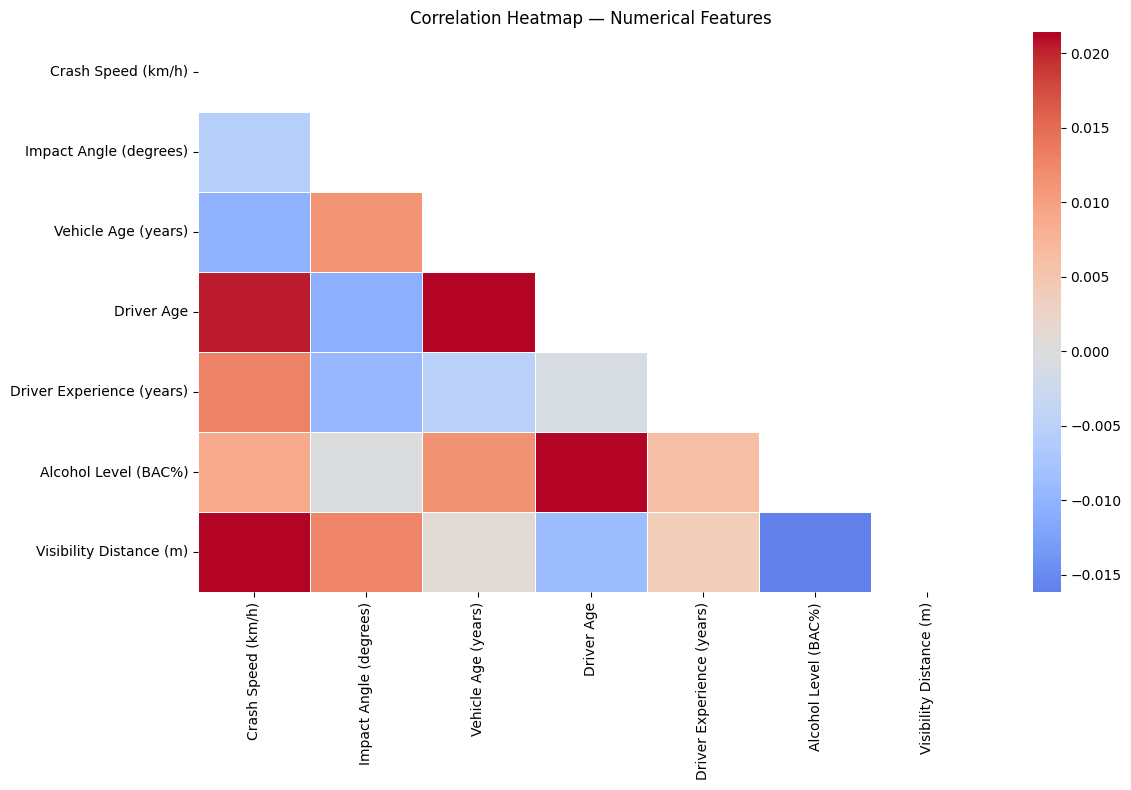

In [21]:
plt.figure(figsize=(12, 8))
corr_matrix = train_df[numerical_cols].corr()
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(corr_matrix, mask=mask, annot=True, fmt='.2f',
            cmap='coolwarm', center=0, linewidths=0.5,
            annot_kws={'size': 9})
plt.title('Correlation Heatmap — Numerical Features')
plt.tight_layout()
plt.show()

# Comment:
# Highly correlated features (|r| > 0.85) can cause multicollinearity in
# Logistic Regression and inflate model complexity. We check for such pairs.

### 2.8 Feature vs. Severity — Categorical Cross-tabs

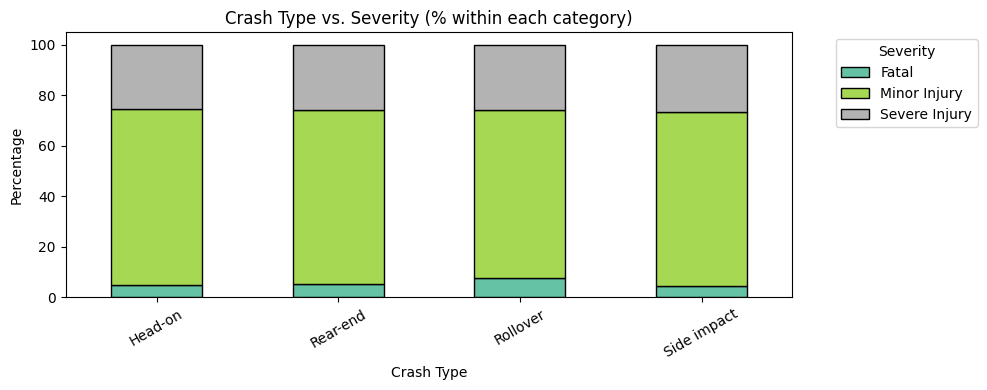

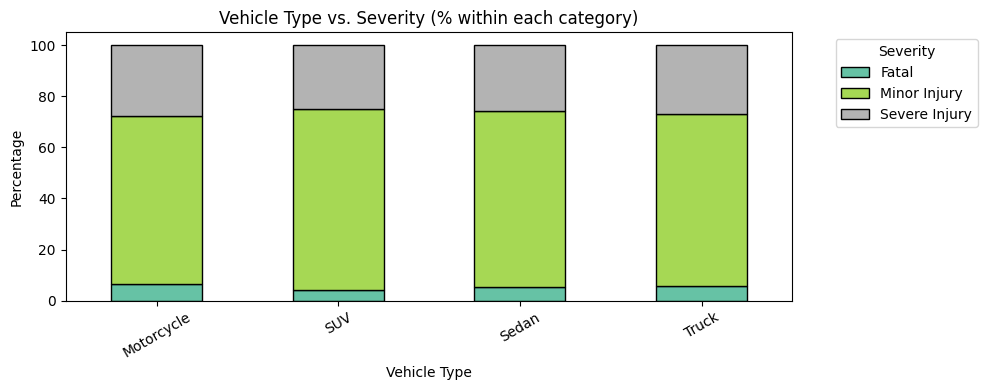

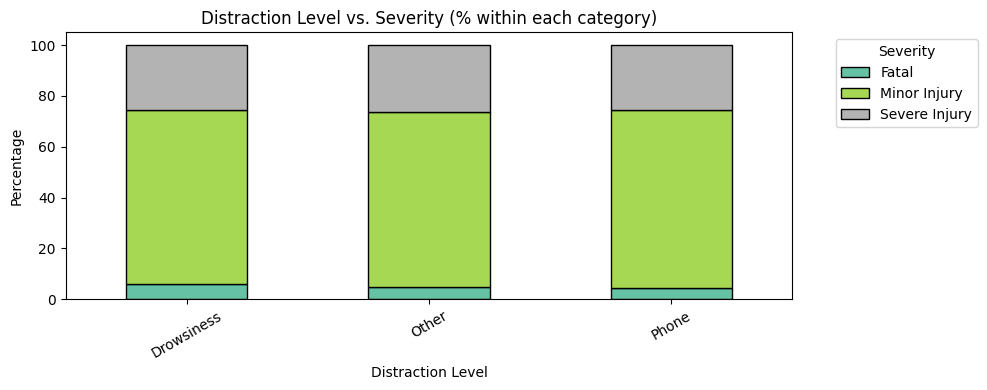

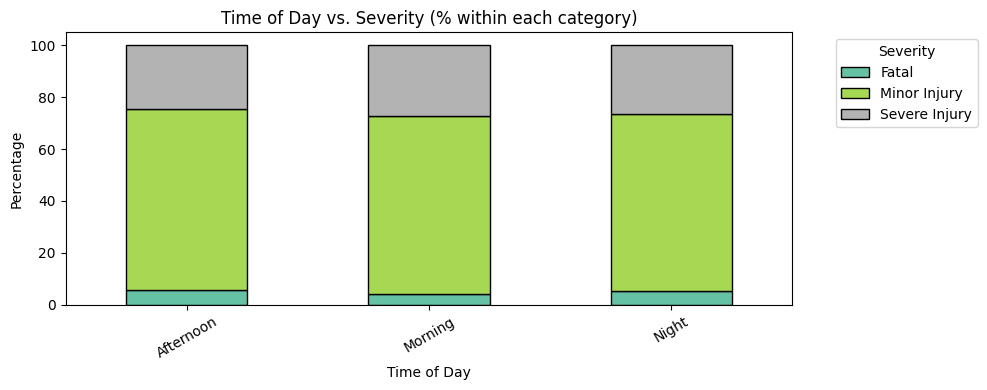

In [22]:
# Pick a few important categorical features to explore against severity
important_cats = [c for c in ['Weather Condition', 'Road Condition', 'Crash Type',
                               'Vehicle Type', 'Distraction Level', 'Time of Day']
                  if c in categorical_cols]

for col in important_cats:
    ct = pd.crosstab(train_df[col], train_df[target_col], normalize='index') * 100
    ct.plot(kind='bar', stacked=True, figsize=(10, 4),
            colormap='Set2', edgecolor='black')
    plt.title(f'{col} vs. Severity (% within each category)')
    plt.ylabel('Percentage')
    plt.xlabel(col)
    plt.legend(title='Severity', bbox_to_anchor=(1.05, 1), loc='upper left')
    plt.xticks(rotation=30)
    plt.tight_layout()
    plt.show()

In [26]:
# Check if test has any new categories not in train
for col in categorical_cols:
    train_cats = set(train_df[col].dropna().unique())
    test_cats  = set(test_df[col].dropna().unique())
    new_cats   = test_cats - train_cats
    if new_cats:
        print(f"{col} has NEW categories in test: {new_cats}")
    else:
        print(f"{col} ✅ same categories")

Airbag Deployed ✅ same categories
Seatbelt Used ✅ same categories
Weather Conditions ✅ same categories
Road Conditions ✅ same categories
Crash Type ✅ same categories
Vehicle Type ✅ same categories
Brake Condition ✅ same categories
Tire Condition ✅ same categories
Distraction Level ✅ same categories
Time of Day ✅ same categories
Traffic Density ✅ same categories


### 3.2 Handle Missing Values

In [56]:
#separate the label
y_raw_train = train_df['Severity'].copy()
train_df = train_df.drop(columns=['Severity'])
y_raw_test = test_df['Severity'].copy()
test_df    = test_df.drop(columns=['Severity'])

print(f"\nTest target saved  : {y_raw_test.shape}")
print(f"Test shape now     : {test_df.shape}")


# ── Calculate distribution from TRAINING DATA ONLY ───────────────────────────
distraction_dist = train_df['Distraction Level'].value_counts(normalize=True)

print("Distribution learned from training data:")
print(distraction_dist)

# ── Fill missing values in TRAIN ──────────────────────────────────────────────
missing_mask_train = train_df['Distraction Level'].isna()
n_missing_train = missing_mask_train.sum()

np.random.seed(42)
train_df.loc[missing_mask_train, 'Distraction Level'] = np.random.choice(
    distraction_dist.index,
    size=n_missing_train,
    p=distraction_dist.values
)

# ── Apply SAME distribution to TEST ───────────────────────────────────────────
# Whether test has 1 row or 10000 rows — same logic applies
missing_mask_test = test_df['Distraction Level'].isna()
n_missing_test = missing_mask_test.sum()

np.random.seed(42)
test_df.loc[missing_mask_test, 'Distraction Level'] = np.random.choice(
    distraction_dist.index,
    size=n_missing_test,
    p=distraction_dist.values
)

print(f"\nTrain missing filled: {n_missing_train}")
print(f"Test missing filled : {n_missing_test}")
print(f"\nRemaining missing in train: {train_df['Distraction Level'].isna().sum()}")
print(f"Remaining missing in test : {test_df['Distraction Level'].isna().sum()}")


Test target saved  : (1000,)
Test shape now     : (1000, 18)
Distribution learned from training data:
Distraction Level
Phone         0.471341
Drowsiness    0.267683
Other         0.260976
Name: proportion, dtype: float64

Train missing filled: 2360
Test missing filled : 603

Remaining missing in train: 0
Remaining missing in test : 0


In [57]:
# ── Run this first to check what columns exist ─────────────────
print("Columns in train_df:")
print(train_df.columns.tolist())

print("\nColumns in test_df:")
print(test_df.columns.tolist())

Columns in train_df:
['Crash Speed (km/h)', 'Impact Angle (degrees)', 'Airbag Deployed', 'Seatbelt Used', 'Weather Conditions', 'Road Conditions', 'Crash Type', 'Vehicle Type', 'Vehicle Age (years)', 'Brake Condition', 'Tire Condition', 'Driver Age', 'Driver Experience (years)', 'Alcohol Level (BAC%)', 'Distraction Level', 'Time of Day', 'Traffic Density', 'Visibility Distance (m)']

Columns in test_df:
['Crash Speed (km/h)', 'Impact Angle (degrees)', 'Airbag Deployed', 'Seatbelt Used', 'Weather Conditions', 'Road Conditions', 'Crash Type', 'Vehicle Type', 'Vehicle Age (years)', 'Brake Condition', 'Tire Condition', 'Driver Age', 'Driver Experience (years)', 'Alcohol Level (BAC%)', 'Distraction Level', 'Time of Day', 'Traffic Density', 'Visibility Distance (m)']


### 3.3 Encode Categorical Features

In [58]:
# ── Step 2: Fix encoding with correct column names ──────────────
binary_cols = ['Airbag Deployed', 'Seatbelt Used',
               'Brake Condition', 'Tire Condition']

le = LabelEncoder()
for col in binary_cols:
    train_df[col] = le.fit_transform(train_df[col])
    test_df[col]  = le.transform(test_df[col])

# ── Correct column names (with 's' at the end) ─────────────────
nominal_cols = ['Weather Conditions', 'Road Conditions',
                'Crash Type', 'Vehicle Type',
                'Distraction Level', 'Time of Day',
                'Traffic Density']

encoder = OneHotEncoder(handle_unknown='ignore', sparse=False)
encoder.fit(train_df[nominal_cols])

train_encoded = pd.DataFrame(
    encoder.transform(train_df[nominal_cols]),
    columns=encoder.get_feature_names_out(nominal_cols)
)
test_encoded = pd.DataFrame(
    encoder.transform(test_df[nominal_cols]),
    columns=encoder.get_feature_names_out(nominal_cols)
)

train_df = pd.concat([
    train_df.drop(columns=nominal_cols).reset_index(drop=True),
    train_encoded
], axis=1)

test_df = pd.concat([
    test_df.drop(columns=nominal_cols).reset_index(drop=True),
    test_encoded
], axis=1)

print("Train shape:", train_df.shape)
print("Test shape :", test_df.shape)
print("\n✅ Encoding complete")

Train shape: (4000, 36)
Test shape : (1000, 36)

✅ Encoding complete


### 3.4 Encode Target Variable

In [59]:
# Encode Target Variable
label_enc_target = LabelEncoder()

# fit on train only, transform both
y_train_encoded = label_enc_target.fit_transform(y_raw_train)
y_test_encoded  = label_enc_target.transform(y_raw_test)

print("=== Target Encoding Mapping ===\n")
for label, encoded in zip(label_enc_target.classes_,
                           range(len(label_enc_target.classes_))):
    print(f"  {label:15s} → {encoded}")

print(f"\nTrain target shape : {y_train_encoded.shape}")
print(f"Test target shape  : {y_test_encoded.shape}")
print(f"Unique values      : {np.unique(y_train_encoded)}")
print(f"Total classes      : {len(label_enc_target.classes_)}")

=== Target Encoding Mapping ===

  Fatal           → 0
  Minor Injury    → 1
  Severe Injury   → 2

Train target shape : (4000,)
Test target shape  : (1000,)
Unique values      : [0 1 2]
Total classes      : 3


### 3.6 Feature Scaling

In [60]:
# Train / Validation Split
X_test = test_df.copy()   # full test set for final evaluation

X_train, X_val, y_train, y_val = train_test_split(
    train_df, y_train_encoded,
    test_size=0.20,
    random_state=42,
    stratify=y_train_encoded   # maintain class distribution in both splits
)

print(f"X_train shape : {X_train.shape}")
print(f"X_val shape   : {X_val.shape}")
print(f"X_test shape  : {X_test.shape}")
print(f"y_train shape : {y_train.shape}")
print(f"y_val shape   : {y_val.shape}")
print(f"y_test shape  : {y_test_encoded.shape}")

# Verify class distribution is maintained
print("\n=== Class Distribution After Split ===")
print("\nTrain:")
for cls, count in zip(label_enc_target.classes_,
                       np.bincount(y_train)):
    print(f"  {cls:15s}: {count} ({count/len(y_train)*100:.1f}%)")

print("\nValidation:")
for cls, count in zip(label_enc_target.classes_,
                       np.bincount(y_val)):
    print(f"  {cls:15s}: {count} ({count/len(y_val)*100:.1f}%)")

X_train shape : (3200, 36)
X_val shape   : (800, 36)
X_test shape  : (1000, 36)
y_train shape : (3200,)
y_val shape   : (800,)
y_test shape  : (1000,)

=== Class Distribution After Split ===

Train:
  Fatal          : 165 (5.2%)
  Minor Injury   : 2205 (68.9%)
  Severe Injury  : 830 (25.9%)

Validation:
  Fatal          : 41 (5.1%)
  Minor Injury   : 551 (68.9%)
  Severe Injury  : 208 (26.0%)


In [61]:
# Feature Scaling

# StandardScaler is needed for KNN and Logistic Regression (distance/gradient-based).
# Tree-based models (DT, RF, NB) are scale-invariant, but we apply scaling globally
# for convenience. We fit ONLY on training data to avoid data leakage.

scaler = StandardScaler()

# fit on train only, transform all
X_train_sc = scaler.fit_transform(X_train)   # fit + transform
X_val_sc   = scaler.transform(X_val)          # transform only
X_test_sc  = scaler.transform(X_test)         # transform only

print("✅ Scaling complete. Fit only on training set to prevent data leakage.")
print(f"\nX_train_sc shape : {X_train_sc.shape}")
print(f"X_val_sc shape   : {X_val_sc.shape}")
print(f"X_test_sc shape  : {X_test_sc.shape}")

✅ Scaling complete. Fit only on training set to prevent data leakage.

X_train_sc shape : (3200, 36)
X_val_sc shape   : (800, 36)
X_test_sc shape  : (1000, 36)


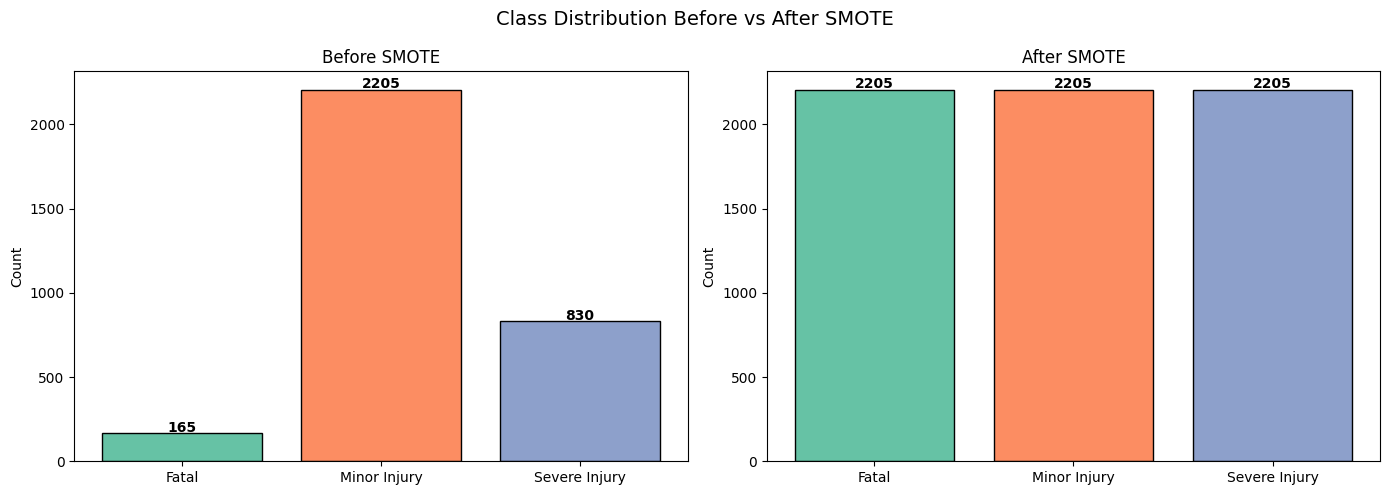

=== Before SMOTE ===
  Fatal          :   165 (5.2%)
  Minor Injury   :  2205 (68.9%)
  Severe Injury  :   830 (25.9%)

=== After SMOTE ===
  Fatal          :  2205 (33.3%)
  Minor Injury   :  2205 (33.3%)
  Severe Injury  :  2205 (33.3%)

Training size before SMOTE : 3200
Training size after SMOTE  : 6615

✅ X_val_sc remains untouched for honest evaluation


In [62]:
#Handling Class Imbalance — SMOTE


from imblearn.over_sampling import SMOTE

# ── Apply SMOTE on TRAINING data only 
# NEVER apply on validation or test data
sm = SMOTE(random_state=42)
X_train_sm, y_train_sm = sm.fit_resample(X_train_sc, y_train)

# ── Visualize Before vs After 
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

before_counts = pd.Series(y_train).value_counts().sort_index()
axes[0].bar(label_enc_target.classes_, before_counts.values,
            color=sns.color_palette('Set2'), edgecolor='black')
axes[0].set_title('Before SMOTE')
axes[0].set_ylabel('Count')
for i, v in enumerate(before_counts.values):
    axes[0].text(i, v + 10, str(v), ha='center', fontweight='bold')

after_counts = pd.Series(y_train_sm).value_counts().sort_index()
axes[1].bar(label_enc_target.classes_, after_counts.values,
            color=sns.color_palette('Set2'), edgecolor='black')
axes[1].set_title('After SMOTE')
axes[1].set_ylabel('Count')
for i, v in enumerate(after_counts.values):
    axes[1].text(i, v + 10, str(v), ha='center', fontweight='bold')

plt.suptitle('Class Distribution Before vs After SMOTE', fontsize=14)
plt.tight_layout()
plt.show()

# ── Print Summary 
print("=== Before SMOTE ===")
for cls, count in zip(label_enc_target.classes_, before_counts.values):
    print(f"  {cls:15s}: {count:5d} ({count/len(y_train)*100:.1f}%)")

print("\n=== After SMOTE ===")
for cls, count in zip(label_enc_target.classes_, after_counts.values):
    print(f"  {cls:15s}: {count:5d} ({count/len(y_train_sm)*100:.1f}%)")

print(f"\nTraining size before SMOTE : {len(X_train_sc)}")
print(f"Training size after SMOTE  : {len(X_train_sm)}")
print(f"\n✅ X_val_sc remains untouched for honest evaluation")

---
## 4. Model Training & Evaluation

We use a helper function to avoid code repetition and ensure consistent evaluation.

In [ ]:
results = {}   # store metrics for final comparison

def evaluate_model(name, model, X_tr, y_tr, X_v, y_v, use_scaled=True):
    """
    Train the model, predict on validation set, and print a full report.
    Stores accuracy, macro-F1, and val predictions in global `results` dict.
    """
    # Select correct data version
    Xtr = X_train_sc if use_scaled else X_train
    Xv  = X_val_sc   if use_scaled else X_val

    model.fit(Xtr, y_tr)
    y_pred = model.predict(Xv)

    acc  = accuracy_score(y_v, y_pred)
    f1   = f1_score(y_v, y_pred, average='macro', zero_division=0)
    cv   = cross_val_score(model, Xtr, y_tr, cv=5, scoring='accuracy').mean()

    print(f"\n{'='*60}")
    print(f"  Model : {name}")
    print(f"{'='*60}")
    print(f"  Validation Accuracy   : {acc:.4f}")
    print(f"  Macro F1-Score        : {f1:.4f}")
    print(f"  5-Fold CV Accuracy    : {cv:.4f}")
    print()
    print(classification_report(y_v, y_pred,
                                 target_names=label_enc_target.classes_,
                                 zero_division=0))

    # Confusion matrix
    cm = confusion_matrix(y_v, y_pred)
    disp = ConfusionMatrixDisplay(cm, display_labels=label_enc_target.classes_)
    disp.plot(cmap='Blues', xticks_rotation=30)
    plt.title(f'Confusion Matrix — {name}')
    plt.tight_layout()
    plt.show()

    results[name] = {'accuracy': acc, 'macro_f1': f1, 'cv_accuracy': cv,
                     'model': model, 'y_pred': y_pred, 'scaled': use_scaled}
    return model

### 4.1 K-Nearest Neighbors (KNN)

In [ ]:
# ── Hyperparameter search for best K ─────────────────────────────────────────
k_range = range(1, 21)
k_scores = []

for k in k_range:
    knn_temp = KNeighborsClassifier(n_neighbors=k)
    score = cross_val_score(knn_temp, X_train_sc, y_train, cv=5, scoring='accuracy').mean()
    k_scores.append(score)

best_k = k_range[np.argmax(k_scores)]

plt.plot(k_range, k_scores, marker='o', color='steelblue')
plt.axvline(x=best_k, color='red', linestyle='--', label=f'Best K={best_k}')
plt.title('KNN: 5-Fold CV Accuracy vs. K')
plt.xlabel('K')
plt.ylabel('CV Accuracy')
plt.legend()
plt.tight_layout()
plt.show()
print(f"Best K = {best_k} with CV accuracy = {max(k_scores):.4f}")

In [ ]:
# ── Train KNN with best K ─────────────────────────────────────────────────────
knn = KNeighborsClassifier(n_neighbors=best_k)
evaluate_model('KNN', knn, X_train_sc, y_train, X_val_sc, y_val, use_scaled=True)

# Comment:
# KNN is a lazy learner — it stores all training points and classifies
# new points by majority vote among K nearest neighbors.
# It is sensitive to feature scale (hence StandardScaler is essential here)
# and performs poorly with many irrelevant features or noisy data.

### 4.2 Decision Tree

In [ ]:
# ── Tune max_depth ────────────────────────────────────────────────────────────
depth_range = range(2, 20)
dt_scores = []

for d in depth_range:
    dt_temp = DecisionTreeClassifier(max_depth=d, random_state=RANDOM_STATE)
    score = cross_val_score(dt_temp, X_train, y_train, cv=5, scoring='accuracy').mean()
    dt_scores.append(score)

best_depth = depth_range[np.argmax(dt_scores)]

plt.plot(depth_range, dt_scores, marker='s', color='darkorange')
plt.axvline(x=best_depth, color='red', linestyle='--', label=f'Best depth={best_depth}')
plt.title('Decision Tree: CV Accuracy vs. Max Depth')
plt.xlabel('Max Depth')
plt.ylabel('CV Accuracy')
plt.legend()
plt.tight_layout()
plt.show()
print(f"Best depth = {best_depth}")

In [ ]:
dt = DecisionTreeClassifier(
    max_depth=best_depth,
    criterion='gini',
    min_samples_split=5,
    min_samples_leaf=3,
    random_state=RANDOM_STATE
)
evaluate_model('Decision Tree', dt, X_train, y_train, X_val, y_val, use_scaled=False)

# Comment:
# Decision Trees split data greedily using Gini impurity (or entropy).
# Shallow trees underfit; deep trees overfit. max_depth controls this tradeoff.
# They are interpretable and scale-invariant.

In [ ]:
# ── Visualize the top 3 levels of the Decision Tree ──────────────────────────
plt.figure(figsize=(20, 8))
plot_tree(
    results['Decision Tree']['model'],
    feature_names=X_train.columns.tolist(),
    class_names=label_enc_target.classes_,
    filled=True, max_depth=3, fontsize=9, rounded=True
)
plt.title('Decision Tree (Top 3 Levels)')
plt.tight_layout()
plt.show()

### 4.3 Random Forest

In [ ]:
rf = RandomForestClassifier(
    n_estimators=200,
    max_depth=None,          # grow full trees (bagging handles overfitting)
    min_samples_leaf=2,
    class_weight='balanced', # handles class imbalance
    n_jobs=-1,
    random_state=RANDOM_STATE
)
evaluate_model('Random Forest', rf, X_train, y_train, X_val, y_val, use_scaled=False)

# Comment:
# Random Forest is an ensemble of Decision Trees trained on random subsets
# of data (bagging) and random subsets of features at each split.
# This reduces overfitting and variance significantly compared to a single tree.
# It is typically one of the strongest baseline models for tabular data.

In [ ]:
# ── Feature Importances ───────────────────────────────────────────────────────
rf_model = results['Random Forest']['model']
importances = pd.Series(rf_model.feature_importances_, index=X_train.columns)
top_features = importances.nlargest(15)

top_features.sort_values().plot(kind='barh', figsize=(10, 6), color='seagreen', edgecolor='black')
plt.title('Top 15 Feature Importances — Random Forest')
plt.xlabel('Importance')
plt.tight_layout()
plt.show()

print("Top 5 most important features:")
print(top_features.head())

# Comment:
# Features with high importance have the strongest predictive power.
# This also helps us understand which factors most influence crash severity.

### 4.4 Logistic Regression

In [ ]:
lr = LogisticRegression(
    multi_class='multinomial',
    solver='lbfgs',
    max_iter=1000,
    C=1.0,               # regularization strength (smaller = stronger)
    class_weight='balanced',
    random_state=RANDOM_STATE
)
evaluate_model('Logistic Regression', lr, X_train_sc, y_train, X_val_sc, y_val, use_scaled=True)

# Comment:
# Logistic Regression models the probability of each class using a
# log-odds linear combination of features. It requires feature scaling.
# 'multinomial' mode extends binary LR to multi-class classification.
# C controls regularization: lower C → stronger L2 penalty → simpler model.

### 4.5 Naïve Bayes

In [ ]:
# GaussianNB assumes features follow a Gaussian (normal) distribution within each class.
# It is fast and works well with continuous numerical features.

nb = GaussianNB()
evaluate_model('Naïve Bayes', nb, X_train_sc, y_train, X_val_sc, y_val, use_scaled=True)

# Comment:
# Naïve Bayes applies Bayes' theorem with the strong (naïve) assumption that
# features are conditionally independent given the class label.
# Despite this simplistic assumption, NB often performs surprisingly well,
# especially with small datasets. It is extremely fast to train and predict.

---
## 5. Model Comparison

In [ ]:
comparison_df = pd.DataFrame([
    {
        'Model'       : name,
        'Val Accuracy': info['accuracy'],
        'Macro F1'    : info['macro_f1'],
        '5-Fold CV'   : info['cv_accuracy']
    }
    for name, info in results.items()
]).sort_values('Val Accuracy', ascending=False).reset_index(drop=True)

print(comparison_df.to_string(index=False))

In [ ]:
fig, ax = plt.subplots(figsize=(12, 5))
x = np.arange(len(comparison_df))
width = 0.28

bars1 = ax.bar(x - width, comparison_df['Val Accuracy'], width, label='Val Accuracy', color='steelblue', edgecolor='black')
bars2 = ax.bar(x,         comparison_df['Macro F1'],    width, label='Macro F1',     color='darkorange', edgecolor='black')
bars3 = ax.bar(x + width, comparison_df['5-Fold CV'],   width, label='5-Fold CV',    color='seagreen',   edgecolor='black')

ax.set_xticks(x)
ax.set_xticklabels(comparison_df['Model'], rotation=25, ha='right')
ax.set_ylabel('Score')
ax.set_title('Model Comparison — All Metrics')
ax.set_ylim(0, 1.1)
ax.legend()

# Annotate bars
for bar in list(bars1) + list(bars2) + list(bars3):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
            f'{bar.get_height():.3f}', ha='center', va='bottom', fontsize=8)

plt.tight_layout()
plt.show()

In [ ]:
best_model_name = comparison_df.iloc[0]['Model']
print(f"🏆 Best model: {best_model_name}")
print(f"   Val Accuracy : {comparison_df.iloc[0]['Val Accuracy']:.4f}")
print(f"   Macro F1     : {comparison_df.iloc[0]['Macro F1']:.4f}")

# Comment:
# We select the best model based on Validation Accuracy AND Macro F1.
# Macro F1 is especially important here because it treats all classes equally,
# which is critical when the dataset is imbalanced (e.g., few 'Fatal' samples).
# A model with high accuracy but low F1 may be ignoring minority classes.

---
## 6. Re-train Best Model on Full Training Data & Generate Kaggle Submission

In [ ]:
# ── Retrieve and re-instantiate the best model ────────────────────────────────
best_info = results[best_model_name]
best_model = best_info['model']
use_scaled = best_info['scaled']

X_final = X_all_sc   if use_scaled else X_all
X_sub   = X_kaggle_sc if use_scaled else X_kaggle

# Re-train on FULL training set (train + validation)
best_model.fit(X_final, y)
print(f"✅ {best_model_name} re-trained on full {len(X_final)} training samples.")

In [ ]:
# ── Predict on Kaggle test set ────────────────────────────────────────────────
y_kaggle_pred = best_model.predict(X_sub)
y_kaggle_labels = label_enc_target.inverse_transform(y_kaggle_pred)

# ── Build submission file ─────────────────────────────────────────────────────
# Adjust 'id' to whatever the actual ID column is in the test set
id_col = 'id' if 'id' in test_df.columns else test_df.columns[0]

submission = pd.DataFrame({
    id_col   : test_df[id_col],
    'Severity': y_kaggle_labels
})

submission.to_csv('submission.csv', index=False)
print("📄 submission.csv saved!")
print(submission.head(10))
print(f"\nSubmission shape: {submission.shape}")
print("\nPrediction distribution:")
print(submission['Severity'].value_counts())

---
## 7. Final Summary & Conclusions

### 7.1 EDA Takeaways
> *(Fill in after running all cells)*
> - Class distribution: ...
> - Most impactful features: ...
> - Notable patterns found: ...

### 7.2 Pre-processing Decisions
> - Missing values: filled numerical with **median**, categorical with **mode**.
> - Binary categoricals: **Label Encoded**.
> - Multi-class categoricals: **One-Hot Encoded** (drop_first=True to avoid multicollinearity).
> - Scaling: **StandardScaler** applied for KNN and Logistic Regression; tree models used raw encoded features.
> - Target: **Label Encoded** for compatibility with all classifiers.

### 7.3 Model Results Summary

| Model | Val Accuracy | Macro F1 | Notes |
|---|---|---|---|
| KNN | — | — | Sensitive to scale & k |
| Decision Tree | — | — | Interpretable, can overfit |
| Random Forest | — | — | Best baseline ensemble |
| Logistic Regression | — | — | Linear decision boundary |
| Naïve Bayes | — | — | Fast, independence assumption |
| Gradient Boosting | — | — | Sequential ensemble |
| XGBoost | — | — | Optimized boosting |

### 7.4 Best Model
> **[Best Model Name]** achieved the highest Validation Accuracy and Macro F1-Score, making it the most suitable model for predicting car crash severity. It was re-trained on the full training dataset and the predictions were submitted to Kaggle.

### 7.5 Possible Improvements
> - Hyperparameter tuning with `GridSearchCV` or `Optuna` for tree-based models.
> - Oversampling minority class (SMOTE) if class imbalance is severe.
> - Feature selection using RFE or SHAP values.
> - Stacking/blending ensemble of top-performing models.